# Generative Adversarial Networks (GANs)

In [50]:
# GAN contains two neural networks:  1.Generator(G)  2.Discriminator(D)

In [51]:
# GAN Architecture:
# Random Noise > Generator > Fake Image > Discriminator > Real or Fake

In [ ]:
# Traditional ML: Input > Prediction
# GAN: Noise > New Image

# GAN can generate: Human faces, Anime characters, Paintings, Cars, Landscapes

In [ ]:
# Adversarial Training Loop

# Step 1 : Generator creates fake image
# Noise > Generator > Fake Face

# Step 2 : Discriminator checks image
# Output: Fake (Correct)

# Step 3: Generator improves
# Creates better fake face

# Step 4: Discriminator improves
# Detects better fakes

# Step 5 : Repeat thousands of times
# Both networks become stronger

In [54]:
# Visual Flow:

# Random Noise > Generator > Fake Image > Discriminator > Real/Fake <-->  Feedback

#### GAN Loss Function

In [55]:
# 1. Generator Loss

# Goal: Fool the Discriminator
# Generator wins when: Fake image looks real

# 2. Discriminator Loss

# Goal: Correctly identify (Real vs Fake)
# Discriminator wins when: (Real = Real, Fake = Fake)

In [56]:
# pip install tensorflow matplotlib

In [57]:
# Step 1: Import Libraries
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Step 2: Load MNIST Dataset
(x_train, x_test), (y_train, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)  # (60000, 28, 28,1)

In [ ]:
# Generator Model


def build_generator():

    model = tf.keras.Sequential(
        [
            layers.Dense(
                128, activation="relu", input_dim=100
            ),  # input:100-random numbers, output:128-neurons
            layers.Dense(784, activation="sigmoid"),  # generate 784 pixel
            layers.Reshape((28, 28, 1)),  # convert 784 value > 28x28 digit image
        ]
    )

    return model

In [ ]:
# Discriminator Model


def build_discriminator():

    model = tf.keras.Sequential(
        [
            layers.Flatten(input_shape=(28, 28, 1)),
            layers.Dense(
                128, activation="relu"
            ),  # learn image pattern(curves, edges, shapes...)
            layers.Dense(1, activation="sigmoid"),
        ]
    )

    return model

In [61]:
# Create Models

generator = build_generator()

discriminator = build_discriminator()

discriminator.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

In [62]:
# Generate Fake Images

noise = np.random.normal(0, 1, (5, 100))  # 5 random noise vectors of size 100
generated_images = generator.predict(noise)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


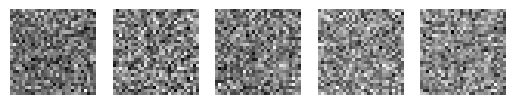

In [63]:
# Display Generated Images  (Noise > Generator > New Digit)

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")

    plt.axis("off")

plt.show()

#### Types of GANs

In [64]:
# 1. DCGAN - Deep Convolutional GAN

# Uses CNN layers
# Best for: Image generation, Face generation
# Example: Random Noise > Human Face

In [65]:
# 2. StyleGAN - Created by NVIDIA.

# Most famous GAN.
# Produces extremely realistic faces.
# Applications: AI avatars, Face generation

In [66]:
# 3. CycleGAN - Converts one image to another image

# Example: Horse → Zebra, Summer → Winter

#### Applications of GANs

In [67]:
# 1. Face Generation - Generate humans that never existed.
# Example : Noise > New Human Face

In [68]:
# 2. Image-to-Image Translation
# CycleGAN: Horse → Zebra

In [69]:
# 3. Deepfakes - Replace one person's face with another.
# Examples: Movies, Entertainment, Social media

In [70]:
# 4. Data Augmentation

In [71]:
# Feature                     AE                 VAE              GAN

# Compression	            Yes              Yes                No
# Reconstruction	        Yes             Yes                No
# Generate New Images	    No              Yes                Yes
# Image Quality	            Medium	        Good	        Excellent
# Complexity	           Easy	            Medium	        Hard

Train a GAN that learns MNIST digits and generates new fake handwritten digits.

In [1]:
# 1. Import Libraries
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 2. Load Dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)

print(x_train.shape)

(60000, 28, 28, 1)


In [4]:
# 3. Build Generator
generator = Sequential(
    [
        layers.Dense(128, activation="relu", input_shape=(100,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(784, activation="sigmoid"),
        layers.Reshape((28, 28, 1)),
    ]
)

generator.summary()

c:\Users\Kaveni Bhadresha\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 247,440 (966.56 KB)

 Trainable params: 247,440 (966.56 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 4. Build Discriminator
discriminator = Sequential(
    [
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

discriminator.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

discriminator.summary()

c:\Users\Kaveni Bhadresha\miniconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,985 (914.00 KB)

 Trainable params: 233,985 (914.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 5. Build GAN

# Freeze discriminator while training generator
# Discriminator will not learn, Discriminator weights will not change
# reason - When training GAN, we want to improve the Generator, not the Discriminator
discriminator.trainable = False

gan = Sequential([generator, discriminator])

gan.compile(optimizer="adam", loss="binary_crossentropy")

In [ ]:
# 6. Training Function

epochs = 5000
batch_size = 64

for epoch in range(epochs):
    # Train Discriminator
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_images = x_train[idx]
    noise = np.random.normal(
        0, 1, (batch_size, 100)
    )  # 64 random noise vectors(rows) of size 100
    fake_images = generator.predict(noise, verbose=0)
    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))
    discriminator.trainable = True

    d_loss_real = discriminator.train_on_batch(real_images, real_labels)

    d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)

    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, 100))
    discriminator.trainable = False
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    # Print Progress
    if epoch % 500 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss_real[0]:.4f} | G Loss: {g_loss:.4f}")

Epoch 0 | D Loss: 0.8009 | G Loss: 0.7055
Epoch 500 | D Loss: 0.0476 | G Loss: 15.8511
Epoch 1000 | D Loss: 0.0239 | G Loss: 13.8725
Epoch 1500 | D Loss: 0.0159 | G Loss: 13.8706
Epoch 2000 | D Loss: 0.0119 | G Loss: 14.0011
Epoch 2500 | D Loss: 0.0096 | G Loss: 14.3451
Epoch 3000 | D Loss: 0.0131 | G Loss: 14.9601
Epoch 3500 | D Loss: 0.0113 | G Loss: 15.0337
Epoch 4000 | D Loss: 0.0099 | G Loss: 15.1804
Epoch 4500 | D Loss: 0.0088 | G Loss: 15.3481


In [9]:
# 7. Generate New Digits

noise = np.random.normal(0, 1, (10, 100))
generated_images = generator.predict(noise)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


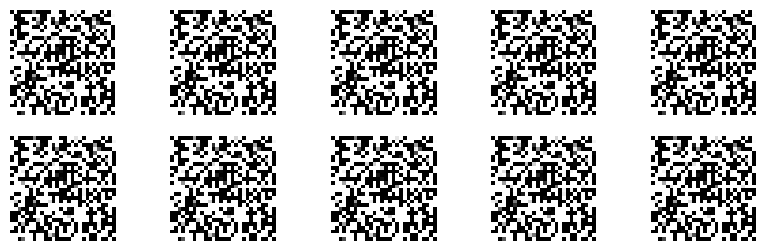

In [10]:
# 8. Visualize Results

plt.figure(figsize=(10, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

(60000, 28, 28, 1)


c:\Users\Kaveni Bhadresha\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 784)            │       402,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 579,728 (2.21 MB)

...

 Total params: 1,113,233 (4.25 MB)

 Trainable params: 579,728 (2.21 MB)

 Non-trainable params: 533,505 (2.04 MB)

c:\Users\Kaveni Bhadresha\miniconda3\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.6776 | D Acc: 61.52% | G Loss: 0.6949
Epoch 5 | D Loss: 1.0207 | D Acc: 32.94% | G Loss: 0.3404
Epoch 10 | D Loss: 1.6400 | D Acc: 29.09% | G Loss: 0.1941
Epoch 15 | D Loss: 2.1378 | D Acc: 28.21% | G Loss: 0.1344
Epoch 20 | D Loss: 2.4534 | D Acc: 27.81% | G Loss: 0.1029
Epoch 25 | D Loss: 2.6638 | D Acc: 27.64% | G Loss: 0.0834
Epoch 30 | D Loss: 2.8157 | D Acc: 27.57% | G Loss: 0.0702
Epoch 35 | D Loss: 2.9317 | D Acc: 27.35% | G Loss: 0.0606
Epoch 40 | D Loss: 3.0241 | D Acc: 27.28% | G Loss: 0.0534
Epoch 45 | D Loss: 3.0992 | D Acc: 27.16% | G Loss: 0.0477
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


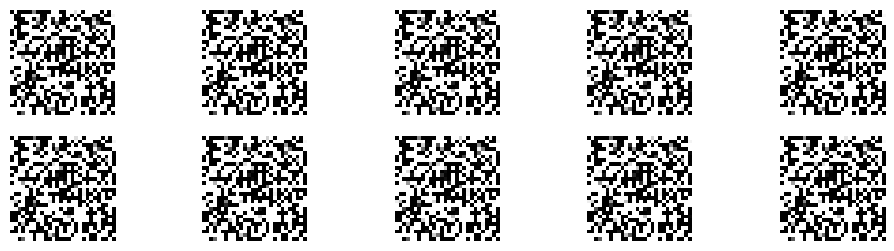

In [8]:
# Import Libraries
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0

# Reshape to (28,28,1)
x_train = x_train.reshape(-1, 28, 28, 1)

print(x_train.shape)


# Build Generator
def build_generator():

    model = tf.keras.Sequential()

    model.add(layers.Dense(128, activation="relu", input_dim=100))

    model.add(layers.Dense(256, activation="relu"))

    model.add(layers.Dense(512, activation="relu"))

    model.add(layers.Dense(784, activation="sigmoid"))

    model.add(layers.Reshape((28, 28, 1)))

    return model


generator = build_generator()

generator.summary()

# Build Discriminator


def build_discriminator():

    model = tf.keras.Sequential()

    model.add(layers.Flatten(input_shape=(28, 28, 1)))

    model.add(layers.Dense(512, activation="relu"))

    model.add(layers.Dense(256, activation="relu"))

    model.add(layers.Dense(1, activation="sigmoid"))

    return model


discriminator = build_discriminator()

discriminator.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

discriminator.summary()

# Create GAN Model
discriminator.trainable = False

gan_input = layers.Input(shape=(100,))

generated_image = generator(gan_input)

gan_output = discriminator(generated_image)

gan = tf.keras.Model(gan_input, gan_output)

gan.compile(optimizer="adam", loss="binary_crossentropy")

gan.summary()

# Training Parameters
epochs = 50

batch_size = 128

noise_dim = 100

# Training Loop

for epoch in range(epochs):

    # -------------------------
    # Train Discriminator
    # -------------------------

    idx = np.random.randint(0, x_train.shape[0], batch_size)

    real_images = x_train[idx]

    noise = np.random.normal(0, 1, (batch_size, noise_dim))

    fake_images = generator.predict(noise, verbose=0)

    real_labels = np.ones((batch_size, 1))

    fake_labels = np.zeros((batch_size, 1))

    d_loss_real = discriminator.train_on_batch(real_images, real_labels)

    d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)

    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # -------------------------
    # Train Generator
    # -------------------------

    noise = np.random.normal(0, 1, (batch_size, noise_dim))

    valid_labels = np.ones((batch_size, 1))

    g_loss = gan.train_on_batch(noise, valid_labels)

    # -------------------------
    # Print Progress
    # -------------------------

    if epoch % 5 == 0:

        print(
            f"Epoch {epoch} | "
            f"D Loss: {d_loss[0]:.4f} | "
            f"D Acc: {d_loss[1]*100:.2f}% | "
            f"G Loss: {g_loss:.4f}"
        )

# Generate New Digits
noise = np.random.normal(0, 1, (10, 100))

generated_images = generator.predict(noise)

# Display Results
plt.figure(figsize=(12, 3))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")

    plt.axis("off")

plt.show()